# 📈 Forecasting de Ventas — ALIV Telecom

Predicción de **altas instaladas** y **ventas registradas** (diarias y mensuales) usando **Holt-Winters Exponential Smoothing**.

| | |
|---|---|
| **Datos** | `winforce_lima_2024`, `winforce_lima_2025`, `winforce_lima` (2026 YTD) |
| **Modelo** | Holt-Winters — tendencia aditiva + estacionalidad semanal (7 días) |
| **Segmentos** | Lima Total · Vertical · Horizontal |
| **Métricas** | Altas (Estado = Ejecutada) · Ventas (con Plan asignado) |

## ⚙️ Configuración

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import sqlalchemy as sa

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'axes.grid.axis':   'y',
})

sys.path.insert(0, os.path.join('..', 'Descargas_Rápidas', 'Pythons'))
from db_config import get_engine

# ── Parámetros ajustables ────────────────────────────────────────
DIAS_FORECAST   = 90       # días hacia el futuro a predecir
VERTICAL_TIPOS  = {'Condominio/Edificio', 'C/E Habilitado'}

C_NARANJA = '#F47920'
C_AZUL    = '#2E86AB'
C_VERDE   = '#1D9E75'
C_VIOLETA = '#7B2D8B'

print('Librerias cargadas OK')

Librerias cargadas OK


## 1. Carga de datos históricos

Unimos los tres años desde SQL Server y los agregamos por día.

In [2]:
engine = get_engine()
hoy    = pd.Timestamp('today').normalize()

altas_raw  = []
ventas_raw = []

tablas = ['winforce_lima_2024', 'winforce_lima_2025', 'winforce_lima']

with engine.connect() as conn:
    insp = sa.inspect(engine)
    for tabla in tablas:
        if not insp.has_table(tabla, schema='dbo'):
            print(f'  [OMITIDO] {tabla} no existe')
            continue

        df_a = pd.read_sql(sa.text(f"""
            SELECT TRY_CONVERT(DATE, LEFT([Fecha programación], 10), 105) AS fecha,
                   [Tipo de domicilio] AS tipo_dom
            FROM [{tabla}]
            WHERE [Estado orden] = 'Ejecutada' AND [Fecha programación] IS NOT NULL
        """), conn)
        df_a['fecha']    = pd.to_datetime(df_a['fecha'])
        df_a['vertical'] = df_a['tipo_dom'].isin(VERTICAL_TIPOS)
        altas_raw.append(df_a)

        df_v = pd.read_sql(sa.text(f"""
            SELECT CAST([Fecha de registro] AS DATE) AS fecha,
                   [Tipo de domicilio] AS tipo_dom
            FROM [{tabla}]
            WHERE [Plan] IS NOT NULL AND [Plan] <> '' AND [Fecha de registro] IS NOT NULL
        """), conn)
        df_v['fecha']    = pd.to_datetime(df_v['fecha'])
        df_v['vertical'] = df_v['tipo_dom'].isin(VERTICAL_TIPOS)
        ventas_raw.append(df_v)

        print(f'  {tabla}: {len(df_a):,} altas  |  {len(df_v):,} ventas')

def serie_diaria(dfs, segmento='total'):
    df = pd.concat(dfs, ignore_index=True)
    df = df[(df['fecha'] >= '2024-01-01') & (df['fecha'] <= hoy)].dropna(subset=['fecha'])
    if segmento == 'vertical':
        df = df[df['vertical']]
    elif segmento == 'horizontal':
        df = df[~df['vertical']]
    daily = df.groupby('fecha').size().reset_index(name='y').rename(columns={'fecha': 'ds'})
    idx   = pd.date_range(daily['ds'].min(), hoy, freq='D')
    daily = daily.set_index('ds').reindex(idx, fill_value=0).reset_index().rename(columns={'index': 'ds'})
    return daily

altas_total  = serie_diaria(altas_raw,  'total')
altas_vert   = serie_diaria(altas_raw,  'vertical')
altas_horiz  = serie_diaria(altas_raw,  'horizontal')
ventas_total = serie_diaria(ventas_raw, 'total')
ventas_vert  = serie_diaria(ventas_raw, 'vertical')
ventas_horiz = serie_diaria(ventas_raw, 'horizontal')

print(f'\nSerie diaria: {len(altas_total)} dias ({altas_total["ds"].min().date()} a {altas_total["ds"].max().date()})')

  winforce_lima_2024: 16,491 altas  |  22,249 ventas
  winforce_lima_2025: 26,116 altas  |  33,968 ventas
  winforce_lima: 12,307 altas  |  16,018 ventas

Serie diaria: 908 dias (2024-01-02 a 2026-06-27)


## 2. Exploración — ¿Cómo se ven los datos históricos?

In [3]:
# Resumen estadístico por año
df_anual = altas_total.copy()
df_anual['anio'] = df_anual['ds'].dt.year
resumen = df_anual.groupby('anio')['y'].agg(['sum','mean','max']).round(1)
resumen.columns = ['Total Altas', 'Promedio/dia', 'Maximo/dia']
print('Altas por año:')
display(resumen)

df_anual_v = ventas_total.copy()
df_anual_v['anio'] = df_anual_v['ds'].dt.year
resumen_v = df_anual_v.groupby('anio')['y'].agg(['sum','mean','max']).round(1)
resumen_v.columns = ['Total Ventas', 'Promedio/dia', 'Maximo/dia']
print('\nVentas por año:')
display(resumen_v)

Altas por año:


,Total Altas,Promedio/dia,Maximo/dia
anio,,,
2024,16413,45.0,100
2025,26128,71.6,129
2026,12373,69.5,107



Ventas por año:


,Total Ventas,Promedio/dia,Maximo/dia
anio,,,
2024,22249,60.8,124
2025,33968,93.1,203
2026,16018,90.0,161


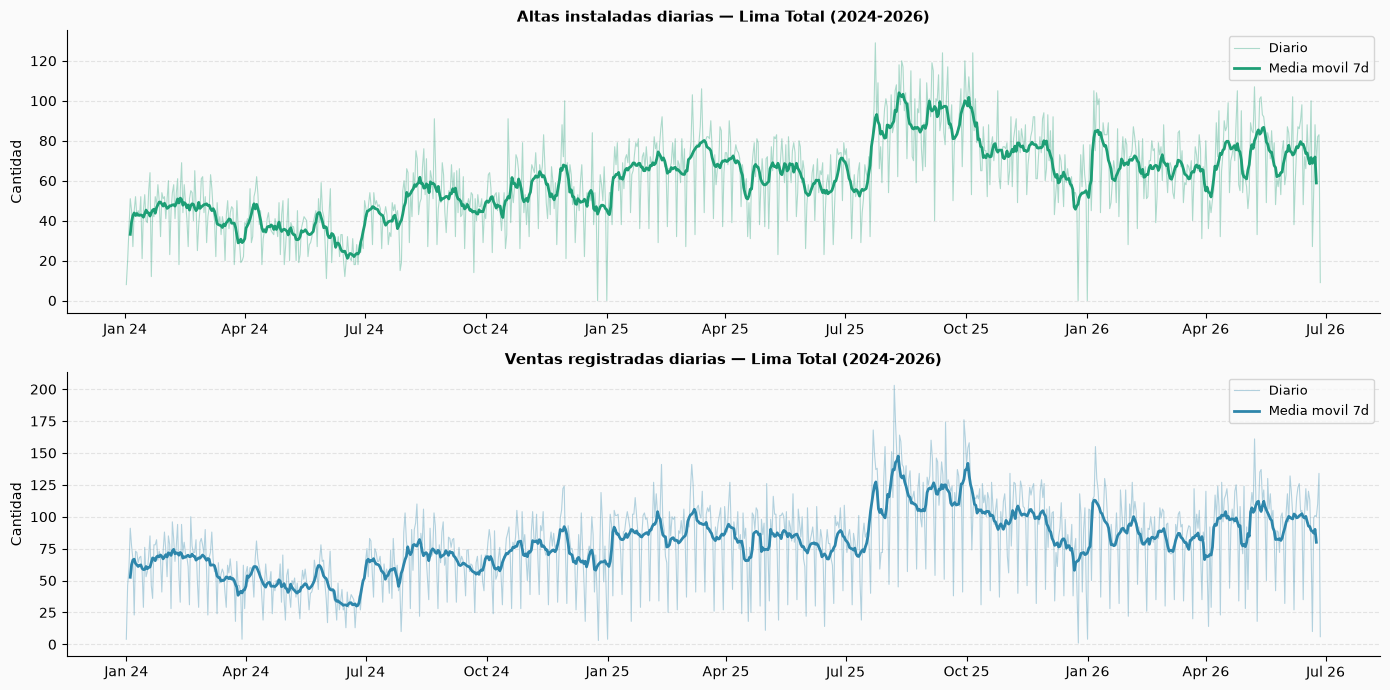

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, df, titulo, color in [
    (axes[0], altas_total,  'Altas instaladas diarias — Lima Total (2024-2026)',  C_VERDE),
    (axes[1], ventas_total, 'Ventas registradas diarias — Lima Total (2024-2026)', C_AZUL),
]:
    mm7 = df.set_index('ds')['y'].rolling(7, center=True).mean()
    ax.plot(df['ds'], df['y'], color=color, alpha=0.35, linewidth=0.8, label='Diario')
    ax.plot(mm7.index, mm7.values, color=color, linewidth=2, label='Media movil 7d')
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Cantidad')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

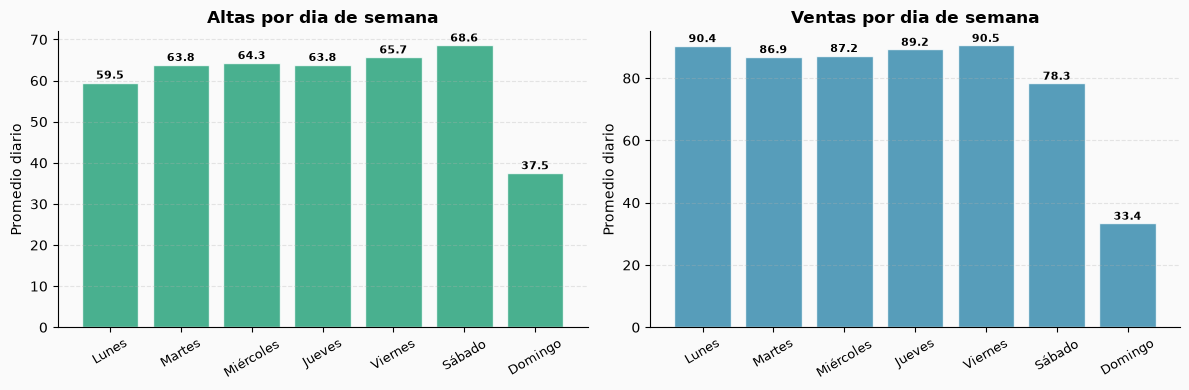

In [5]:
# Patrón semanal: ¿qué días se vende más?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

for ax, df, titulo, color in [
    (axes[0], altas_total,  'Altas por dia de semana',  C_VERDE),
    (axes[1], ventas_total, 'Ventas por dia de semana', C_AZUL),
]:
    df_tmp = df.copy()
    df_tmp['dow'] = df_tmp['ds'].dt.dayofweek
    avg = df_tmp.groupby('dow')['y'].mean()
    bars = ax.bar([dias_semana[i] for i in avg.index], avg.values,
                  color=color, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Promedio diario')
    plt.sca(ax)
    plt.xticks(rotation=30, fontsize=9)

plt.tight_layout()
plt.show()

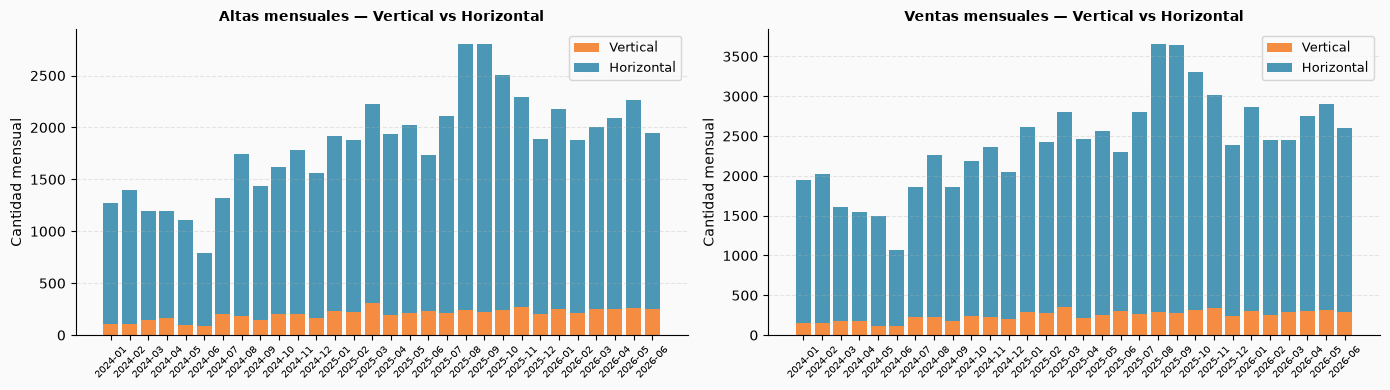

In [6]:
# Vertical vs Horizontal — distribución mensual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df_v, df_h, titulo in [
    (axes[0], altas_vert,  altas_horiz,  'Altas mensuales — Vertical vs Horizontal'),
    (axes[1], ventas_vert, ventas_horiz, 'Ventas mensuales — Vertical vs Horizontal'),
]:
    def mens(df):
        d = df.copy()
        d['mes'] = d['ds'].dt.to_period('M')
        return d.groupby('mes')['y'].sum()

    mv = mens(df_v)
    mh = mens(df_h)
    meses = [str(m) for m in mv.index]
    ax.bar(meses, mv.values, label='Vertical',    color=C_NARANJA, alpha=0.85)
    ax.bar(meses, mh.values, label='Horizontal',  color=C_AZUL,    alpha=0.85, bottom=mv.values)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_ylabel('Cantidad mensual')
    ax.legend(fontsize=9)
    plt.sca(ax)
    plt.xticks(rotation=45, fontsize=7)

plt.tight_layout()
plt.show()

## 3. Modelo de forecasting — Holt-Winters

Holt-Winters Exponential Smoothing combina:
- **Nivel**: promedio base de la serie
- **Tendencia**: dirección de crecimiento/decrecimiento
- **Estacionalidad**: patrón semanal (7 días)

Es ideal para ventas con comportamiento semanal repetitivo y tendencia de largo plazo.

In [7]:
def entrenar_hw(df_diario, dias=DIAS_FORECAST):
    """Entrena Holt-Winters y devuelve (df_forecast, fit)."""
    df = df_diario.sort_values('ds').set_index('ds')
    serie = df['y'].astype(float).clip(lower=0)

    modelo = ExponentialSmoothing(
        serie,
        trend='add',
        seasonal='add',
        seasonal_periods=7,
        initialization_method='estimated',
    )
    fit  = modelo.fit(optimized=True, use_brute=False)
    pred = fit.forecast(dias).clip(lower=0)

    rmse  = np.sqrt(np.mean(fit.resid**2))
    lower = (pred - 1.96 * rmse).clip(lower=0)
    upper =  pred + 1.96 * rmse

    df_fc = pd.DataFrame({'ds': pred.index, 'yhat': pred.round(1),
                          'lower': lower.round(1), 'upper': upper.round(1)})
    return df_fc, fit

print('Entrenando modelos...')
fc_altas_total,  fit_at = entrenar_hw(altas_total)
fc_altas_vert,   fit_av = entrenar_hw(altas_vert)
fc_altas_horiz,  fit_ah = entrenar_hw(altas_horiz)
fc_ventas_total, fit_vt = entrenar_hw(ventas_total)
fc_ventas_vert,  fit_vv = entrenar_hw(ventas_vert)
fc_ventas_horiz, fit_vh = entrenar_hw(ventas_horiz)
print('Modelos entrenados OK')

Entrenando modelos...
Modelos entrenados OK


## 4. Resultados — Altas Instaladas

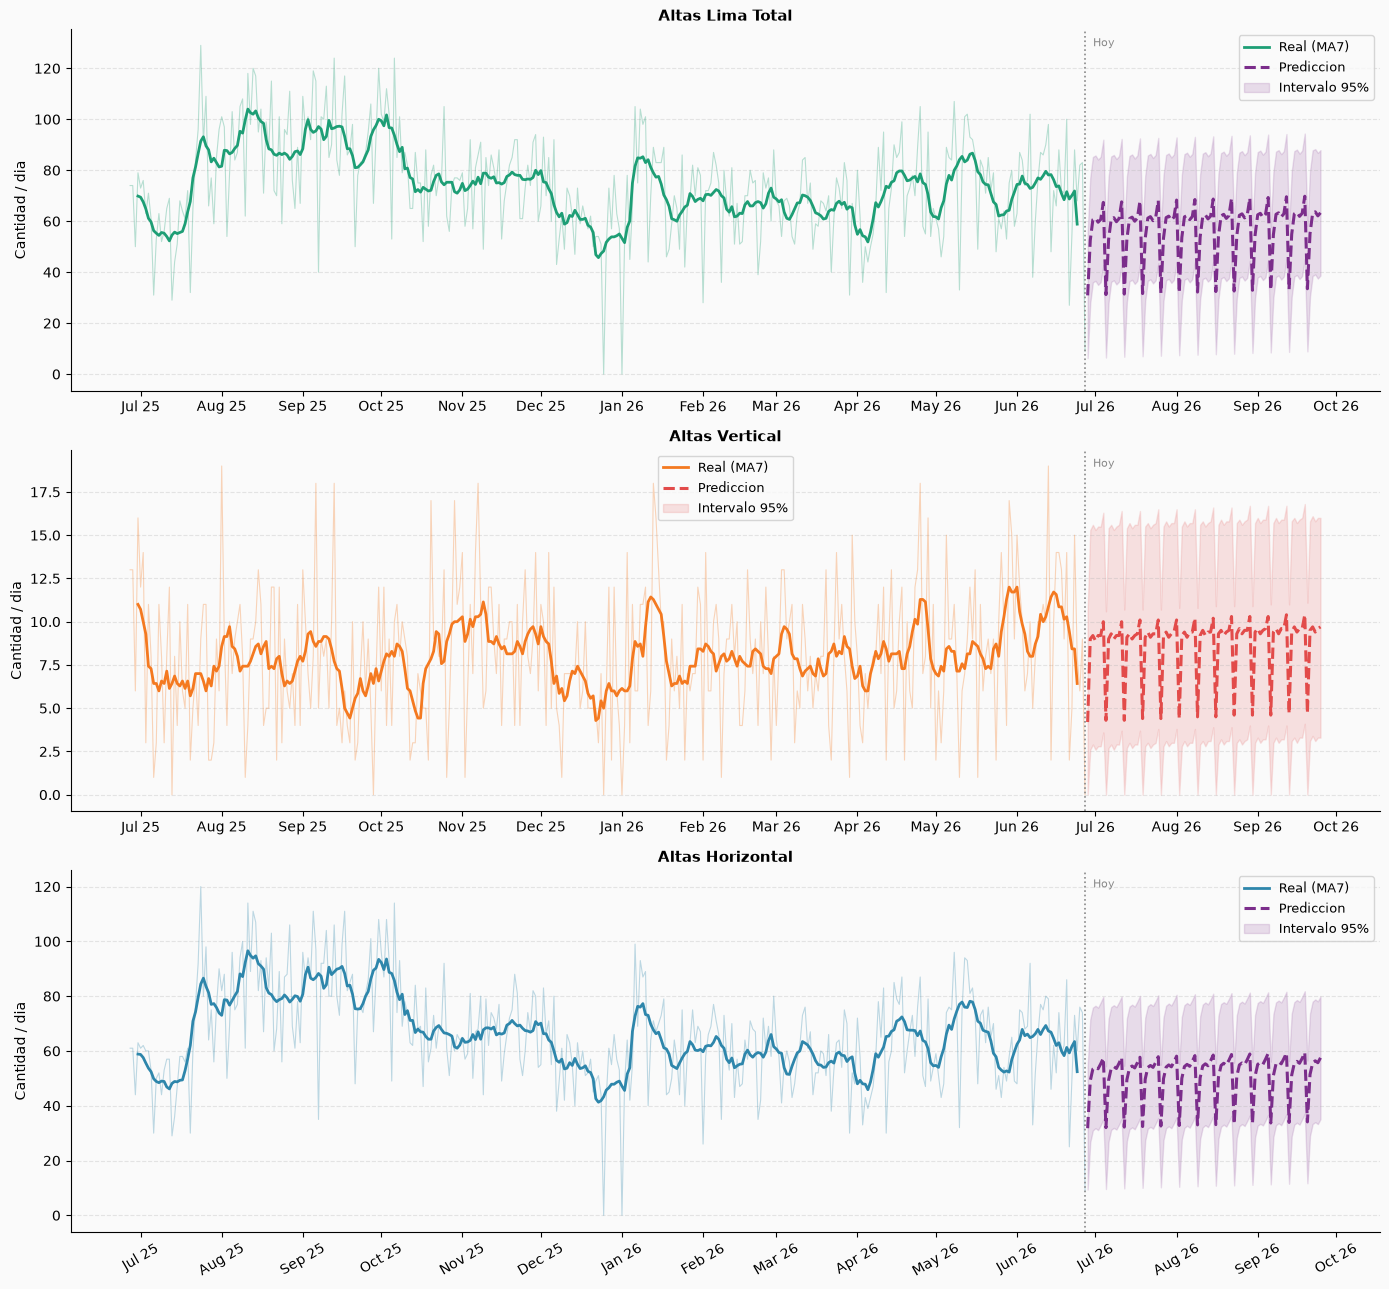

In [8]:
def plot_forecast_diario(df_hist, df_fc, titulo, color_hist, color_pred, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4.5))
    
    # Últimos 12 meses de histórico
    df_h = df_hist[df_hist['ds'] >= hoy - pd.Timedelta(days=365)].copy()
    mm7  = df_h.set_index('ds')['y'].rolling(7, center=True).mean()

    ax.plot(df_h['ds'], df_h['y'],  color=color_hist, alpha=0.3, linewidth=0.8)
    ax.plot(mm7.index,  mm7.values, color=color_hist, linewidth=2,  label='Real (MA7)')
    ax.plot(df_fc['ds'], df_fc['yhat'],  color=color_pred, linewidth=2.2,
            linestyle='--', label='Prediccion')
    ax.fill_between(df_fc['ds'], df_fc['lower'], df_fc['upper'],
                    color=color_pred, alpha=0.15, label='Intervalo 95%')
    ax.axvline(hoy, color='#888', linestyle=':', linewidth=1.2)
    ax.text(hoy, ax.get_ylim()[1]*0.95, '  Hoy', color='#888', fontsize=8)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Cantidad / dia')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.legend(fontsize=9)
    plt.xticks(rotation=30)
    return ax

fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_forecast_diario(altas_total, fc_altas_total, 'Altas Lima Total',  C_VERDE,   C_VIOLETA, axes[0])
plot_forecast_diario(altas_vert,  fc_altas_vert,  'Altas Vertical',    C_NARANJA, C_ROJO if hasattr(plt, '_rc_params') else '#E24B4A', axes[1])
plot_forecast_diario(altas_horiz, fc_altas_horiz, 'Altas Horizontal',  C_AZUL,    C_VIOLETA, axes[2])
plt.tight_layout()
plt.show()

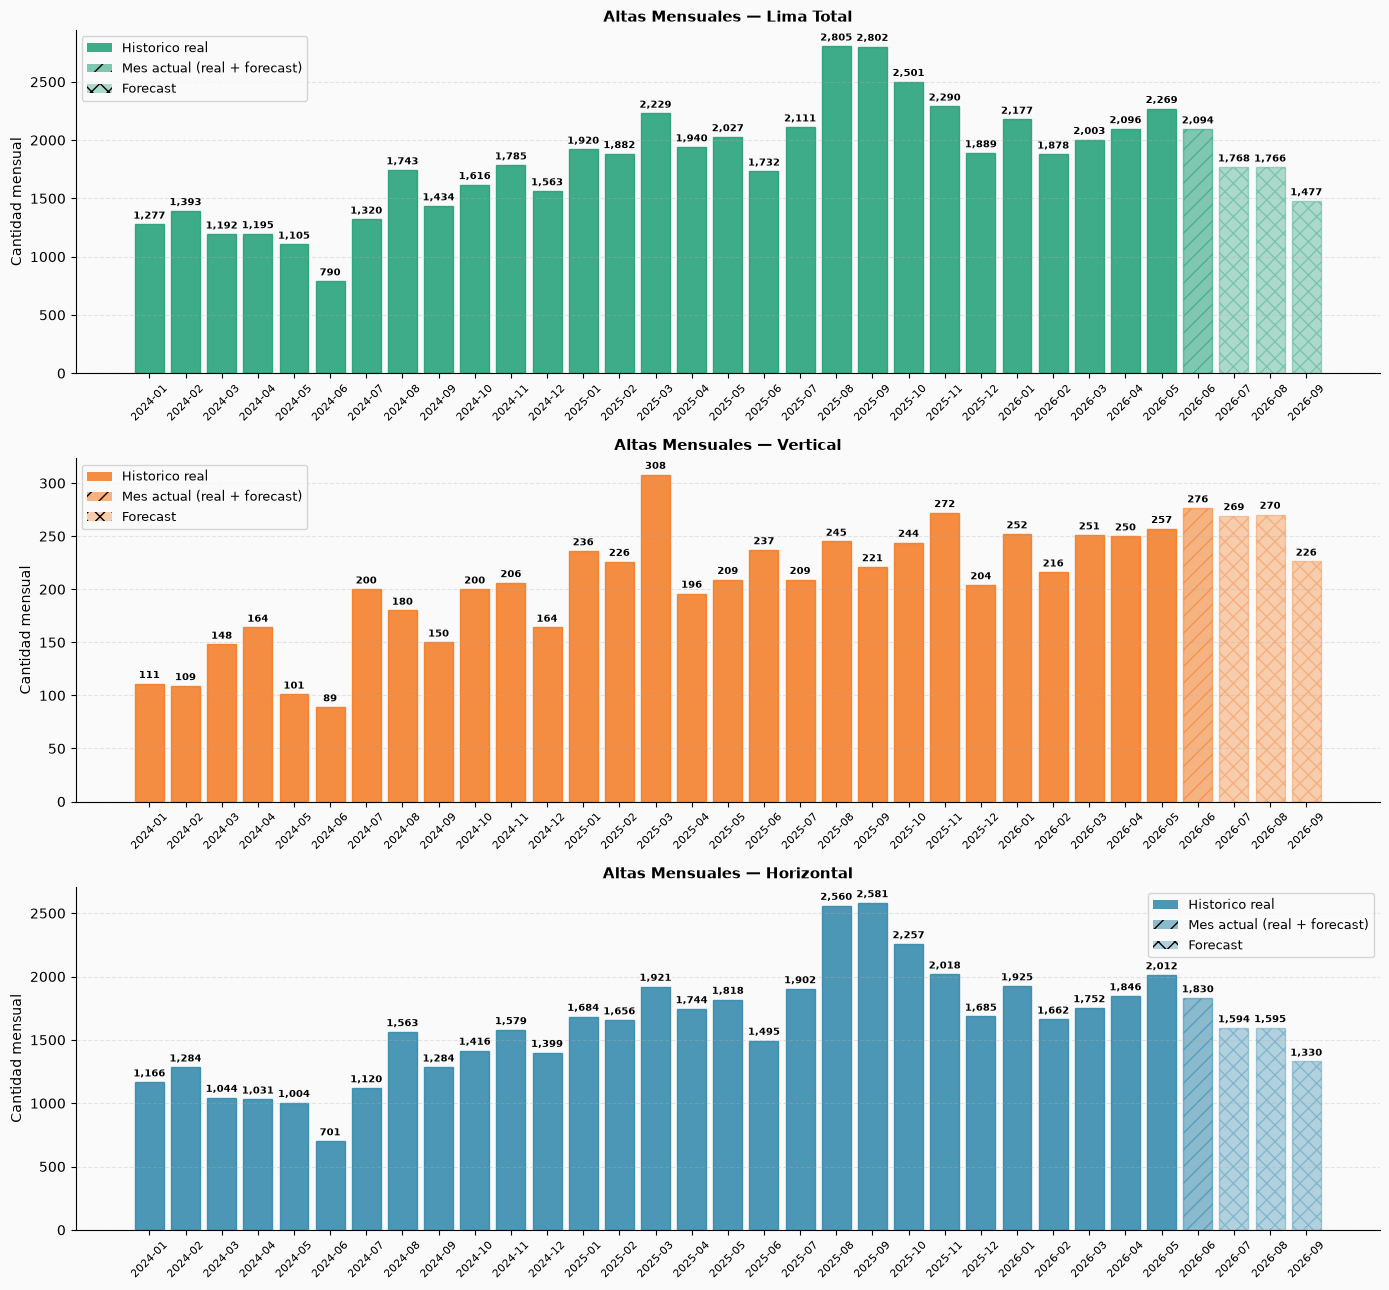

In [9]:
def forecast_mensual(df_hist, df_fc):
    """Combina histórico y forecast en una tabla mensual con proyección total."""
    hist = df_hist.copy()
    hist['mes'] = hist['ds'].dt.to_period('M')
    hist_m = hist.groupby('mes')['y'].sum().reset_index(name='real')

    fc = df_fc.copy()
    fc['mes'] = fc['ds'].dt.to_period('M')
    fc_m = fc.groupby('mes')['yhat'].sum().reset_index(name='forecast')

    m = hist_m.merge(fc_m, on='mes', how='outer').sort_values('mes').fillna(0)
    mes_act = pd.Period(hoy, 'M')

    def proyeccion(row):
        if row['mes'] < mes_act:
            return row['real']
        elif row['mes'] == mes_act:
            return row['real'] + row['forecast']  # real acumulado + resto del mes
        else:
            return row['forecast']

    m['proyeccion'] = m.apply(proyeccion, axis=1)
    m['tipo'] = m['mes'].apply(
        lambda x: 'Historico' if x < mes_act else ('Mes actual' if x == mes_act else 'Forecast')
    )
    return m

def plot_mensual(df_hist, df_fc, titulo, color, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4.5))
    m = forecast_mensual(df_hist, df_fc)
    meses_str = [str(x) for x in m['mes']]
    colores   = [color if t == 'Historico' else (color if t == 'Mes actual' else color) for t in m['tipo']]
    alphas    = [0.85 if t == 'Historico' else (0.55 if t == 'Mes actual' else 0.35) for t in m['tipo']]
    hatch     = ['' if t == 'Historico' else ('//' if t == 'Mes actual' else 'xx') for t in m['tipo']]

    bars = ax.bar(meses_str, m['proyeccion'], color=colores, edgecolor=color)
    for bar, a, h in zip(bars, alphas, hatch):
        bar.set_alpha(a)
        bar.set_hatch(h)
    for i, val in enumerate(m['proyeccion']):
        ax.text(i, val + max(m['proyeccion'])*0.01, f'{int(round(val)):,}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Cantidad mensual')
    legend_elements = [
        Patch(facecolor=color, alpha=0.85, label='Historico real'),
        Patch(facecolor=color, alpha=0.55, hatch='//', label='Mes actual (real + forecast)'),
        Patch(facecolor=color, alpha=0.35, hatch='xx', label='Forecast'),
    ]
    ax.legend(handles=legend_elements, fontsize=9)
    plt.sca(ax)
    plt.xticks(rotation=45, fontsize=8)
    return ax

fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_mensual(altas_total, fc_altas_total, 'Altas Mensuales — Lima Total',  C_VERDE,   axes[0])
plot_mensual(altas_vert,  fc_altas_vert,  'Altas Mensuales — Vertical',    C_NARANJA, axes[1])
plot_mensual(altas_horiz, fc_altas_horiz, 'Altas Mensuales — Horizontal',  C_AZUL,    axes[2])
plt.tight_layout()
plt.show()

## 5. Resultados — Ventas Registradas

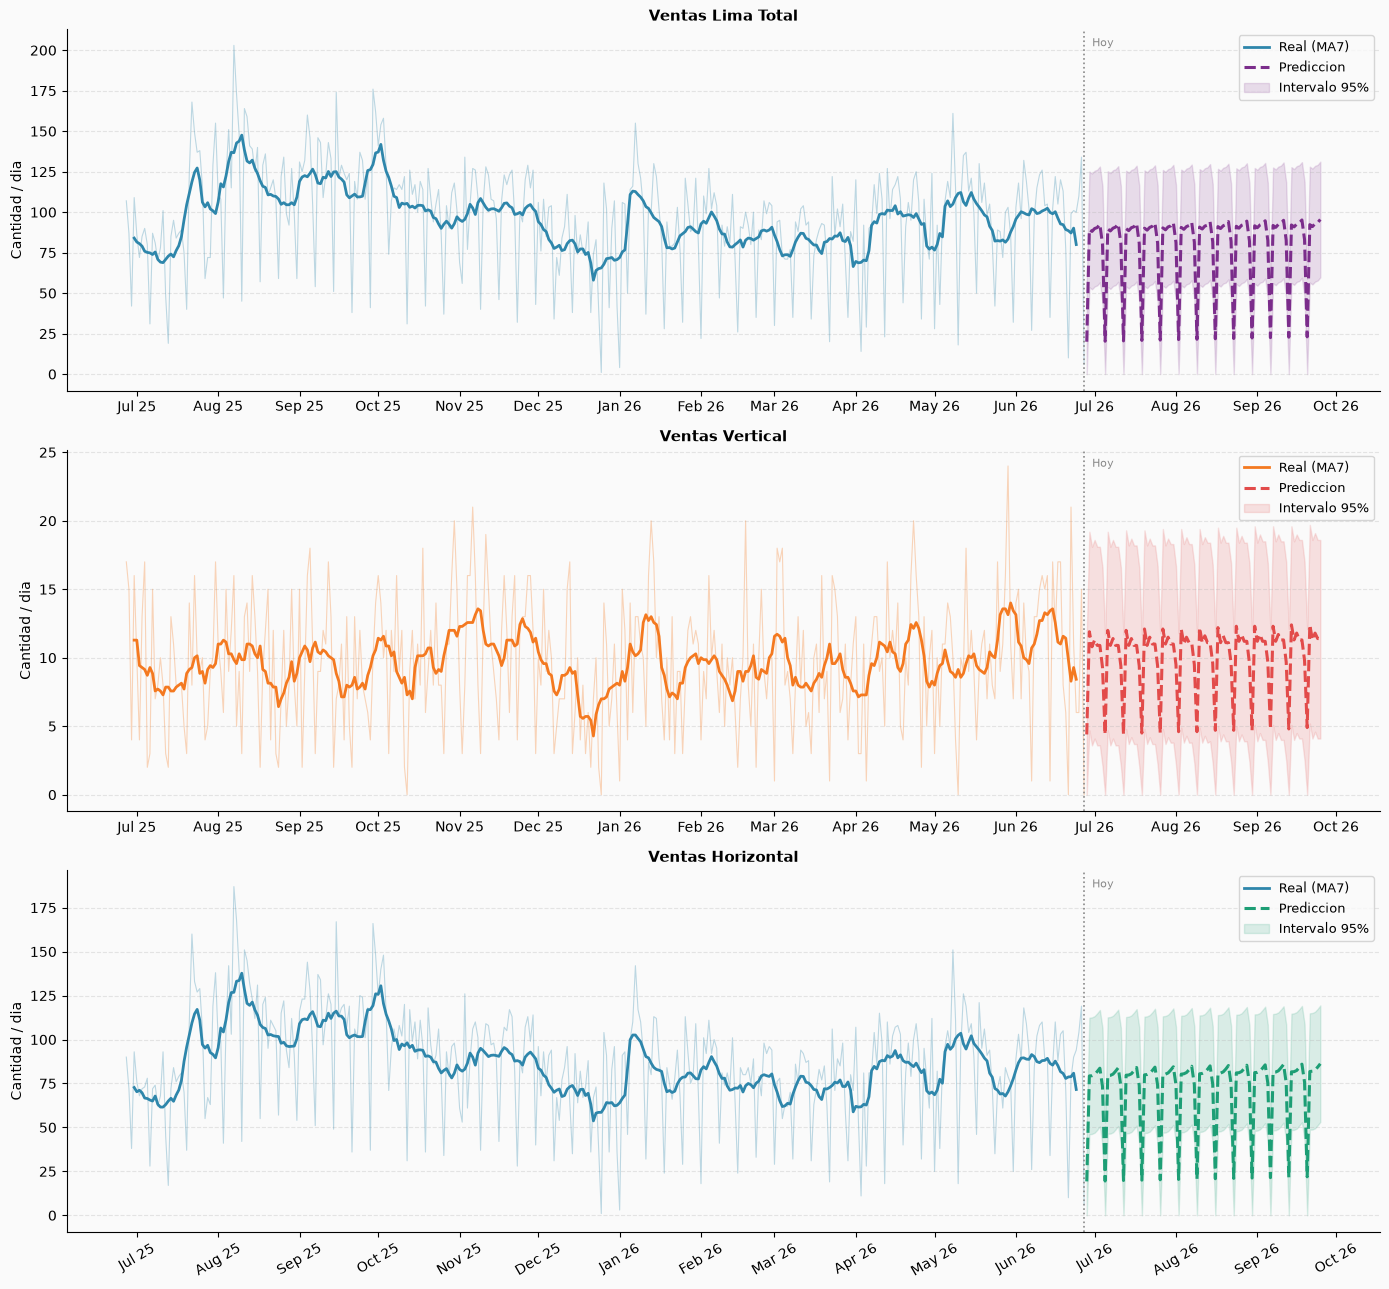

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_forecast_diario(ventas_total, fc_ventas_total, 'Ventas Lima Total', C_AZUL,    C_VIOLETA, axes[0])
plot_forecast_diario(ventas_vert,  fc_ventas_vert,  'Ventas Vertical',   C_NARANJA, '#E24B4A',  axes[1])
plot_forecast_diario(ventas_horiz, fc_ventas_horiz, 'Ventas Horizontal', C_AZUL,    C_VERDE,    axes[2])
plt.tight_layout()
plt.show()

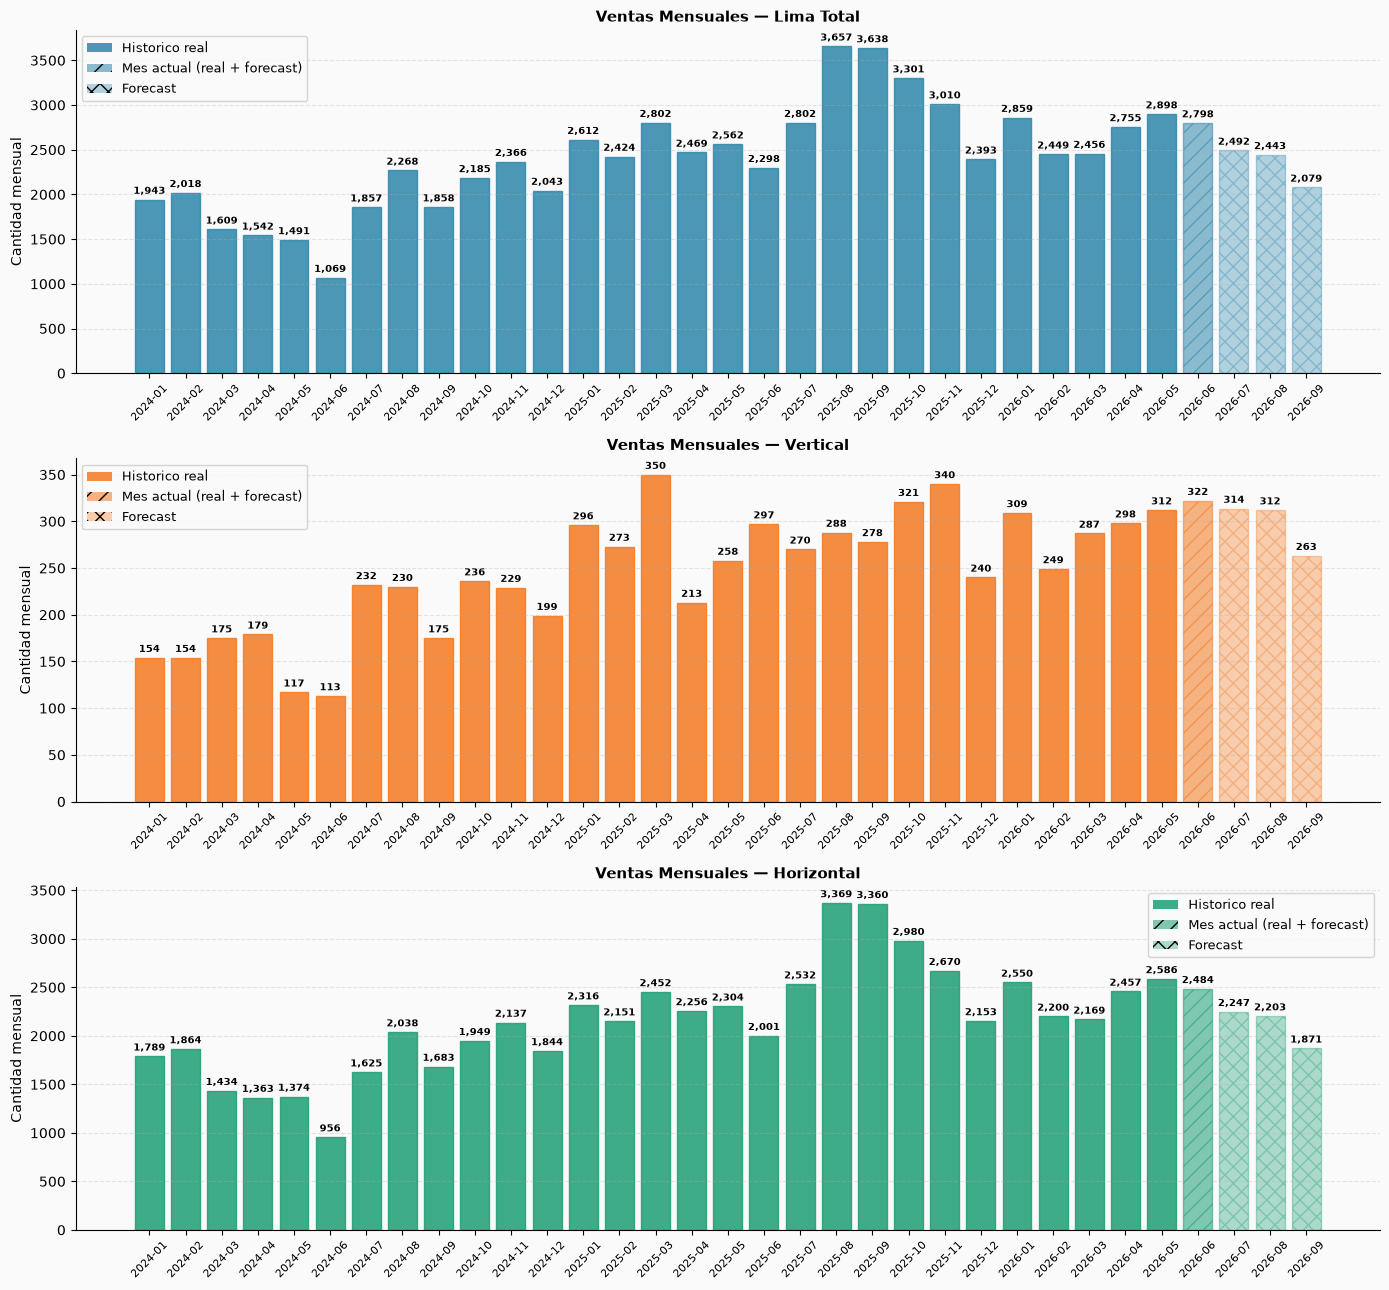

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
plot_mensual(ventas_total, fc_ventas_total, 'Ventas Mensuales — Lima Total', C_AZUL,    axes[0])
plot_mensual(ventas_vert,  fc_ventas_vert,  'Ventas Mensuales — Vertical',   C_NARANJA, axes[1])
plot_mensual(ventas_horiz, fc_ventas_horiz, 'Ventas Mensuales — Horizontal', C_VERDE,   axes[2])
plt.tight_layout()
plt.show()

## 6. Tabla resumen — Proyección mensual consolidada

In [12]:
from IPython.display import display
import pandas as pd

def tabla_proyeccion_mensual():
    series = {
        'Altas Total':    (altas_total,  fc_altas_total),
        'Altas Vert':     (altas_vert,   fc_altas_vert),
        'Altas Horiz':    (altas_horiz,  fc_altas_horiz),
        'Ventas Total':   (ventas_total, fc_ventas_total),
        'Ventas Vert':    (ventas_vert,  fc_ventas_vert),
        'Ventas Horiz':   (ventas_horiz, fc_ventas_horiz),
    }
    rows = {}
    for nombre, (hist, fc) in series.items():
        m = forecast_mensual(hist, fc).set_index('mes')['proyeccion']
        rows[nombre] = m
    
    df_res = pd.DataFrame(rows)
    df_res.index = [str(i) for i in df_res.index]
    df_res = df_res.round(0).astype(int)
    
    mes_act = str(pd.Period(hoy, 'M'))
    
    def colorear(val):
        return 'color: #1D9E75; font-weight: bold' if val > 0 else ''
    
    return df_res

df_resumen = tabla_proyeccion_mensual()

mes_act = str(pd.Period(hoy, 'M'))
styled = (df_resumen.style
    .set_caption('Proyeccion mensual — Historico + Forecast (Holt-Winters)')
    .format('{:,}')
    .highlight_between(subset=df_resumen.columns, color='#FFF3E0',
                       left=1, right=999999,
                       props='font-weight: bold')
    .set_properties(**{'text-align': 'center', 'font-size': '11px'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#1C1C1E'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center')]
    }])
)
display(styled)

,Altas Total,Altas Vert,Altas Horiz,Ventas Total,Ventas Vert,Ventas Horiz
2024-01,"1,277",111,"1,166","1,943",154,"1,789"
2024-02,"1,393",109,"1,284","2,018",154,"1,864"
2024-03,"1,192",148,"1,044","1,609",175,"1,434"
2024-04,"1,195",164,"1,031","1,542",179,"1,363"
2024-05,"1,105",101,"1,004","1,491",117,"1,374"
2024-06,790,89,701,"1,069",113,956
2024-07,"1,320",200,"1,120","1,857",232,"1,625"
2024-08,"1,743",180,"1,563","2,268",230,"2,038"
2024-09,"1,434",150,"1,284","1,858",175,"1,683"
2024-10,"1,616",200,"1,416","2,185",236,"1,949"


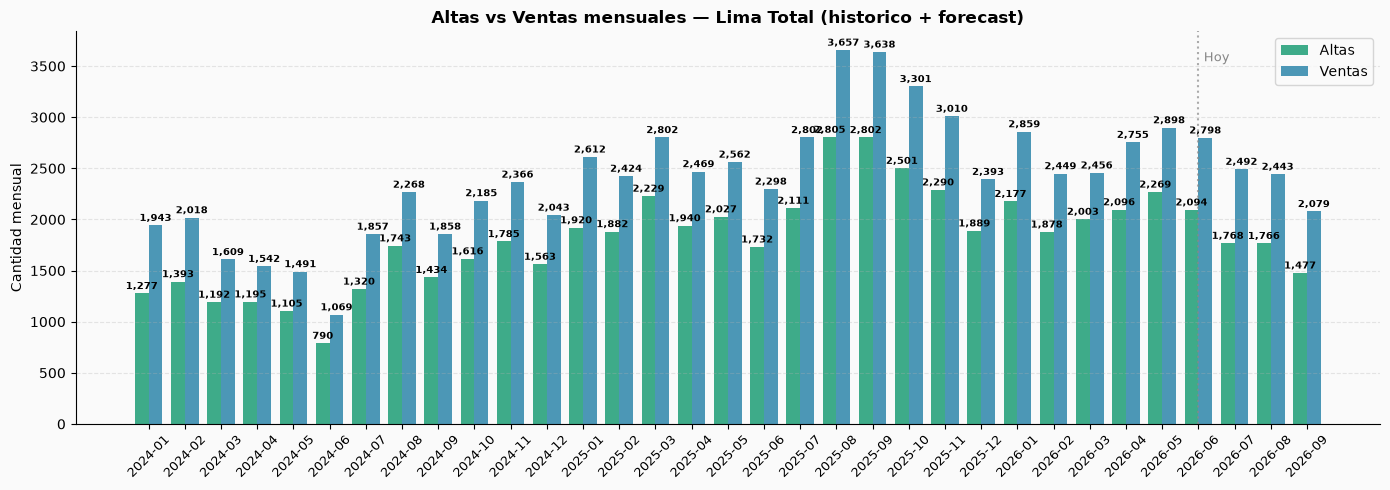

In [13]:
# Gráfico comparativo: Altas vs Ventas por mes
fig, ax = plt.subplots(figsize=(14, 5))

m_altas  = forecast_mensual(altas_total,  fc_altas_total)
m_ventas = forecast_mensual(ventas_total, fc_ventas_total)

# Solo los meses en el rango del forecast
meses = sorted(set(m_altas['mes']) | set(m_ventas['mes']))
meses_str = [str(m) for m in meses]
idx = range(len(meses))

altas_vals  = [m_altas[m_altas['mes'] == m]['proyeccion'].sum()  for m in meses]
ventas_vals = [m_ventas[m_ventas['mes'] == m]['proyeccion'].sum() for m in meses]

width = 0.38
bars1 = ax.bar([i - width/2 for i in idx], altas_vals,  width, label='Altas',  color=C_VERDE,   alpha=0.85)
bars2 = ax.bar([i + width/2 for i in idx], ventas_vals, width, label='Ventas', color=C_AZUL,    alpha=0.85)

for bar, val in zip(list(bars1) + list(bars2), altas_vals + ventas_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ventas_vals)*0.005,
            f'{int(round(val)):,}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(list(idx))
ax.set_xticklabels(meses_str, rotation=45, fontsize=9)
ax.set_title('Altas vs Ventas mensuales — Lima Total (historico + forecast)', fontweight='bold', fontsize=12)
ax.set_ylabel('Cantidad mensual')
ax.legend(fontsize=10)

# Línea vertical en mes actual
mes_act_idx = meses_str.index(str(pd.Period(hoy, 'M'))) if str(pd.Period(hoy, 'M')) in meses_str else None
if mes_act_idx is not None:
    ax.axvline(mes_act_idx, color='#888', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(mes_act_idx + 0.15, max(ventas_vals)*0.97, 'Hoy', color='#888', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Exportar a Excel (opcional)

Genera el mismo archivo `.xlsx` con tablas y gráficos embebidos.

In [14]:
import subprocess, sys as _sys
from datetime import date

resultado = subprocess.run(
    [_sys.executable, 'forecasting_ventas.py', f'--dias', str(DIAS_FORECAST)],
    capture_output=True, text=True
)
print(resultado.stdout)
if resultado.returncode != 0:
    print('STDERR:', resultado.stderr)


  FORECASTING VENTAS ALIV â€” 90 dÃ­as de predicciÃ³n

[ 1/4 ] Cargando datos histÃ³ricos...
  winforce_lima_2024: 16,491 altas
  winforce_lima_2024: 22,249 ventas
  winforce_lima_2025: 26,116 altas
  winforce_lima_2025: 33,968 ventas
  winforce_lima: 12,307 altas
  winforce_lima: 16,018 ventas
  Total registros cargados: 5,449 filas diarias

[ 2/4 ] Entrenando modelos Holt-Winters...
  Altas Lima Total          -> proximos 30 dias: 1,666  |  proximos 90 dias: 5,155
  Altas Vertical            -> proximos 30 dias: 254  |  proximos 90 dias: 788
  Altas Horizontal          -> proximos 30 dias: 1,509  |  proximos 90 dias: 4,652
  Ventas Lima Total         -> proximos 30 dias: 2,324  |  proximos 90 dias: 7,211
  Ventas Vertical           -> proximos 30 dias: 296  |  proximos 90 dias: 916
  Ventas Horizontal         -> proximos 30 dias: 2,097  |  proximos 90 dias: 6,500

[ 3/4 ] Generando Excel con tablas y grÃ¡ficos...
  Guardado: c:\Users\Usuario\Documents\Code Aliv\Python Automate\Forec